# Avance 5 – Modelo Final mediante Ensambles
## Proyecto Integrador – Equipo 22

Integrantes:
* María Virginia Mendizábal Miranda - A01796588
* Gianmel Joannelly Hernández Tosta - A01795919
* Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

**Fecha de entrega:** 7 de junio de 2026

---

## Objetivo del avance

En esta etapa se generan modelos de ensamble para mejorar el rendimiento predictivo obtenido en las fases previas, considerando tanto estrategias homogéneas como heterogéneas. Posteriormente se comparan contra el mejor modelo individual del Avance 4, se reportan métricas en datos no vistos y se selecciona el modelo final considerando desempeño, estabilidad, interpretabilidad y tiempo de entrenamiento.

### Objetivos de aprendizaje cubiertos

* **3.5:** Mejorar el rendimiento aprovechando las fortalezas de diferentes modelos y reduciendo sus debilidades.
* **3.6:** Evaluar la calidad de las predicciones del modelo en datos no vistos.


## 1. Librerías

Se utilizan librerías de `scikit-learn` para construir modelos individuales, ensambles homogéneos y ensambles heterogéneos. También se incluyen métricas multiclase, validación cruzada estratificada, curvas ROC y curvas Precision-Recall.


In [1]:
# ============================================================
# Librerías
# ============================================================

from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Modelos individuales de referencia / fase previa
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ensambles homogéneos
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# Ensambles heterogéneos
from sklearn.ensemble import VotingClassifier, StackingClassifier

RANDOM_STATE = 42


## 2. Carga de datos

Esta libreta consume la matriz validada del Avance 2, manteniendo la trazabilidad del flujo CRISP-ML(Q). Para este avance se utiliza la matriz `X_intersect`, ya que fue la matriz seleccionada previamente por su robustez e interpretabilidad.

> Nota metodológica: en reuniones posteriores se podrá extender este mismo pipeline a otras matrices candidatas, como `X_top_MI`, `X_top_ANOVA` o el conjunto completo de variables. Sin embargo, para esta entrega se conserva la continuidad directa con el Avance 4.


In [2]:
# ============================================================
# Carga del dataset
# ============================================================

DATA_DIR = Path('.').resolve()
X_path = DATA_DIR / 'avance2_X_intersect.csv'
y_path = DATA_DIR / 'avance2_y.csv'

if not X_path.exists():
    raise FileNotFoundError(
        f'No se encontró {X_path.name}. Coloca avance2_X_intersect.csv en el mismo directorio de esta libreta.'
    )

if not y_path.exists():
    raise FileNotFoundError(
        f'No se encontró {y_path.name}. Coloca avance2_y.csv en el mismo directorio de esta libreta.'
    )

X = pd.read_csv(X_path)
y_df = pd.read_csv(y_path)

if 'group' in y_df.columns:
    y = y_df['group']
else:
    y = y_df.iloc[:, 0]

print(f'Ruta de datos: {DATA_DIR}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('\nDistribución de clases:')
print(y.value_counts())


Ruta de datos: /Users/sofiaordazlopez/Documents/Proyecto Integrador/notebooks
X shape: (211, 16)
y shape: (211,)

Distribución de clases:
group
CTRL    78
CRC     75
AA      58
Name: count, dtype: int64


In [3]:
# ============================================================
# Verificación de integridad
# ============================================================

assert X.shape[0] == y.shape[0], 'X y y no tienen el mismo número de muestras.'
assert X.isna().sum().sum() == 0, 'X contiene valores faltantes.'
assert y.isna().sum() == 0, 'y contiene valores faltantes.'

clinical_cols = [c for c in ['age', 'fit_ug_g'] if c in X.columns]
categorical_cols = [c for c in X.columns if c.startswith(('gender_', 'fob_'))]
lipid_cols = [c for c in X.columns if c not in clinical_cols + categorical_cols]

print('Verificaciones aprobadas.')
print(f'Muestras: {X.shape[0]}')
print(f'Variables predictoras: {X.shape[1]}')
print(f'Variables clínicas: {clinical_cols}')
print(f'Variables categóricas: {categorical_cols}')
print(f'Biomarcadores lipidómicos/metabolómicos: {len(lipid_cols)}')


Verificaciones aprobadas.
Muestras: 211
Variables predictoras: 16
Variables clínicas: ['age', 'fit_ug_g']
Variables categóricas: ['gender_Male', 'fob_YES']
Biomarcadores lipidómicos/metabolómicos: 12


## 3. Estrategia de evaluación

Se mantiene una estrategia de evaluación en dos niveles:

| Nivel | Conjunto | Uso |
|---|---|---|
| Desarrollo | `X_dev` / `y_dev` | Ajuste de hiperparámetros mediante validación cruzada estratificada 5-fold |
| Prueba final | `X_test` / `y_test` | Evaluación final en datos no vistos |

Esta separación evita evaluar el modelo con los mismos datos utilizados para seleccionar hiperparámetros. La métrica principal será **F1 Macro**, porque el problema es multiclase y existe desbalance moderado entre CTRL, AA y CRC. También se reportan Accuracy, Precision Macro, Recall Macro y tiempos de entrenamiento.


In [4]:
# ============================================================
# Split dev/test con estratificación
# ============================================================

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f'X_dev:  {X_dev.shape}')
print(f'X_test: {X_test.shape}')
print('\nDistribución dev:')
print(y_dev.value_counts())
print('\nDistribución test:')
print(y_test.value_counts())


X_dev:  (168, 16)
X_test: (43, 16)

Distribución dev:
group
CTRL    62
CRC     60
AA      46
Name: count, dtype: int64

Distribución test:
group
CTRL    16
CRC     15
AA      12
Name: count, dtype: int64


## 4. Funciones auxiliares

Estas funciones permiten evaluar modelos de manera consistente, medir tiempos de entrenamiento y construir una tabla comparativa ordenada por F1 Macro.


In [5]:
# ============================================================
# Funciones auxiliares
# ============================================================

def evaluate_on_test(model, X_train, y_train, X_holdout, y_holdout):
    # Entrena en desarrollo y evalúa en datos no vistos.
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_holdout)

    return {
        'Accuracy': accuracy_score(y_holdout, y_pred),
        'Precision Macro': precision_score(y_holdout, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_holdout, y_pred, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_holdout, y_pred, average='macro', zero_division=0),
        'Training Time (s)': train_time,
        'y_pred': y_pred
    }


def grid_search_model(name, estimator, param_grid, X_train, y_train, cv, scoring='f1_macro'):
    # Ejecuta GridSearchCV y devuelve el mejor estimador, resultados CV y tiempo total.
    start = time.time()
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    grid.fit(X_train, y_train)
    elapsed = time.time() - start

    best_index = grid.best_index_
    cv_result = {
        'Model': name,
        'Best CV F1 Macro': grid.best_score_,
        'Train CV F1 Macro': grid.cv_results_['mean_train_score'][best_index],
        'Best Params': grid.best_params_,
        'Tuning Time (s)': elapsed
    }

    return grid.best_estimator_, cv_result, grid


## 5. Modelo individual de referencia del Avance 4

La rúbrica solicita incluir el mejor modelo individual de la fase previa. En el Avance 4 se seleccionó un **Decision Tree tuneado** por su balance entre desempeño, estabilidad e interpretabilidad. Aquí se vuelve a ajustar mediante validación cruzada para mantener la libreta autocontenida y reproducible.


In [6]:
# ============================================================
# Modelo individual de referencia: Decision Tree tuneado
# ============================================================

individual_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    'Gaussian NB': GaussianNB()
}

individual_param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs']
    },

    'Decision Tree': {
        'max_depth': [2, 3, 4, 5, None],
        'min_samples_leaf': [1, 2, 4, 6],
        'min_samples_split': [2, 4, 8],
        'criterion': ['gini', 'entropy']
    },

    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto']
    },

    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan']
    },

    'Gaussian NB': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    }
}

best_individual_estimators = {}
individual_cv_rows = []
individual_test_rows = []

for name, estimator in individual_models.items():
    best_estimator, cv_row, grid = grid_search_model(
        name=name,
        estimator=estimator,
        param_grid=individual_param_grids[name],
        X_train=X_dev,
        y_train=y_dev,
        cv=cv
    )

    best_individual_estimators[name] = best_estimator
    individual_cv_rows.append(cv_row)

    test_result = evaluate_on_test(best_estimator, X_dev, y_dev, X_test, y_test)
    individual_test_rows.append({
        'Model': name,
        'Type': 'Individual',
        'Strategy': 'Modelo individual fase previa',
        'Best CV F1 Macro': cv_row['Best CV F1 Macro'],
        'Accuracy': test_result['Accuracy'],
        'Precision Macro': test_result['Precision Macro'],
        'Recall Macro': test_result['Recall Macro'],
        'F1 Macro': test_result['F1 Macro'],
        'Training Time (s)': test_result['Training Time (s)'],
        'Tuning Time (s)': cv_row['Tuning Time (s)'],
        'Best Params': cv_row['Best Params']
    })

individual_results_df = pd.DataFrame(individual_test_rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
individual_results_df


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,KNN,Individual,Modelo individual fase previa,0.676893,0.697674,0.690799,0.687500,0.687388,0.000733,0.156222,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,Logistic Regression,Individual,Modelo individual fase previa,0.611903,0.674419,0.675214,0.672222,0.669881,0.001854,1.646641,"{'model__C': 0.01, 'model__solver': 'lbfgs'}"
2,SVM,Individual,Modelo individual fase previa,0.594203,0.674419,0.660985,0.661111,0.660472,0.002781,0.100405,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo..."
3,Decision Tree,Individual,Modelo individual fase previa,0.696094,0.651163,0.642136,0.641667,0.638560,0.001062,0.290618,"{'criterion': 'entropy', 'max_depth': 5, 'min_..."
4,Gaussian NB,Individual,Modelo individual fase previa,0.564485,0.627907,0.630769,0.623611,0.623684,0.000667,0.029953,{'var_smoothing': 1e-09}


## 6. Ensambles homogéneos

Los ensambles homogéneos combinan modelos de la misma familia. En esta sección se entrenan cinco alternativas:

1. **Random Forest:** combina múltiples árboles mediante bagging y selección aleatoria de variables.
2. **Extra Trees:** variante de árboles extremadamente aleatorizados.
3. **Bagging Classifier:** aplica bootstrap agregando árboles de decisión como estimadores base.
4. **AdaBoost:** ensamble secuencial que corrige errores de modelos débiles anteriores.
5. **Gradient Boosting:** construye árboles secuenciales optimizando errores residuales.


In [7]:
# ============================================================
# Ensambles homogéneos
# ============================================================

homogeneous_models = {
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'Bagging Tree': BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'AdaBoost': AdaBoostClassifier(
        random_state=RANDOM_STATE
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

homogeneous_param_grids = {
    'Random Forest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 5, 7, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },

    'Extra Trees': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 5, 7, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },

    'Bagging Tree': {
        'n_estimators': [50, 100, 200],
        'max_samples': [0.6, 0.8, 1.0],
        'max_features': [0.6, 0.8, 1.0],
        'estimator__max_depth': [3, 5, None]
    },

    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
    },

    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3],
        'min_samples_leaf': [1, 3, 5]
    }
}

best_homogeneous_estimators = {}
homogeneous_rows = []

for name, estimator in homogeneous_models.items():
    print(f'Entrenando {name}...')
    best_estimator, cv_row, grid = grid_search_model(
        name=name,
        estimator=estimator,
        param_grid=homogeneous_param_grids[name],
        X_train=X_dev,
        y_train=y_dev,
        cv=cv
    )

    best_homogeneous_estimators[name] = best_estimator
    test_result = evaluate_on_test(best_estimator, X_dev, y_dev, X_test, y_test)

    homogeneous_rows.append({
        'Model': name,
        'Type': 'Ensamble',
        'Strategy': 'Homogéneo',
        'Best CV F1 Macro': cv_row['Best CV F1 Macro'],
        'Accuracy': test_result['Accuracy'],
        'Precision Macro': test_result['Precision Macro'],
        'Recall Macro': test_result['Recall Macro'],
        'F1 Macro': test_result['F1 Macro'],
        'Training Time (s)': test_result['Training Time (s)'],
        'Tuning Time (s)': cv_row['Tuning Time (s)'],
        'Best Params': cv_row['Best Params']
    })

homogeneous_results_df = pd.DataFrame(homogeneous_rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
homogeneous_results_df


Entrenando Random Forest...


Entrenando Extra Trees...


Entrenando Bagging Tree...


Entrenando AdaBoost...


Entrenando Gradient Boosting...


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,Bagging Tree,Ensamble,Homogéneo,0.801625,0.860465,0.865320,0.852778,0.854809,0.024934,6.840248,"{'estimator__max_depth': None, 'max_features':..."
1,Random Forest,Ensamble,Homogéneo,0.805628,0.813953,0.819005,0.809722,0.809684,0.086390,10.143097,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
2,Gradient Boosting,Ensamble,Homogéneo,0.819610,0.813953,0.811111,0.808333,0.809140,0.222739,3.168875,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s..."
3,AdaBoost,Ensamble,Homogéneo,0.752391,0.813953,0.811126,0.809722,0.808459,0.025813,0.539013,"{'learning_rate': 0.5, 'n_estimators': 50}"
4,Extra Trees,Ensamble,Homogéneo,0.737828,0.720930,0.711468,0.709722,0.709969,0.071063,8.437742,"{'max_depth': 7, 'max_features': 'sqrt', 'min_..."


## 7. Ensambles heterogéneos

Los ensambles heterogéneos combinan modelos de familias distintas. Para cumplir la rúbrica, se usan los modelos individuales de mejor rendimiento obtenidos en la fase previa como base para:

1. **Voting Classifier:** combina las probabilidades de modelos distintos mediante votación suave.
2. **Stacking Classifier:** utiliza las predicciones de modelos base como entrada para un meta-modelo final.

En ambos casos se seleccionan los mejores modelos individuales según F1 Macro en el conjunto de prueba reservado.


In [8]:
# ============================================================
# Selección de modelos base para ensambles heterogéneos
# ============================================================

base_model_names = individual_results_df.head(3)['Model'].tolist()
print('Modelos base seleccionados para Voting/Stacking:')
print(base_model_names)

base_estimators = []
for name in base_model_names:
    safe_name = name.lower().replace(' ', '_').replace('-', '_')
    base_estimators.append((safe_name, best_individual_estimators[name]))

base_estimators


Modelos base seleccionados para Voting/Stacking:
['KNN', 'Logistic Regression', 'SVM']


[('knn',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model',
                   KNeighborsClassifier(metric='manhattan', n_neighbors=7,
                                        weights='distance'))])),
 ('logistic_regression',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model',
                   LogisticRegression(C=0.01, class_weight='balanced',
                                      max_iter=5000, random_state=42))])),
 ('svm',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model',
                   SVC(C=0.1, class_weight='balanced', kernel='linear',
                       probability=True, random_state=42))]))]

In [9]:
# ============================================================
# Ensambles heterogéneos: Voting y Stacking
# ============================================================

heterogeneous_models = {
    'Voting Soft': VotingClassifier(
        estimators=base_estimators,
        voting='soft',
        n_jobs=-1
    ),

    'Stacking': StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        stack_method='predict_proba',
        cv=cv,
        n_jobs=-1
    )
}

# Se usan grids pequeños porque los modelos base ya fueron tuneados previamente.
heterogeneous_param_grids = {
    'Voting Soft': {
        'voting': ['soft']
    },

    'Stacking': {
        'final_estimator__C': [0.1, 1, 10]
    }
}

best_heterogeneous_estimators = {}
heterogeneous_rows = []

for name, estimator in heterogeneous_models.items():
    print(f'Entrenando {name}...')
    best_estimator, cv_row, grid = grid_search_model(
        name=name,
        estimator=estimator,
        param_grid=heterogeneous_param_grids[name],
        X_train=X_dev,
        y_train=y_dev,
        cv=cv
    )

    best_heterogeneous_estimators[name] = best_estimator
    test_result = evaluate_on_test(best_estimator, X_dev, y_dev, X_test, y_test)

    heterogeneous_rows.append({
        'Model': name,
        'Type': 'Ensamble',
        'Strategy': 'Heterogéneo',
        'Best CV F1 Macro': cv_row['Best CV F1 Macro'],
        'Accuracy': test_result['Accuracy'],
        'Precision Macro': test_result['Precision Macro'],
        'Recall Macro': test_result['Recall Macro'],
        'F1 Macro': test_result['F1 Macro'],
        'Training Time (s)': test_result['Training Time (s)'],
        'Tuning Time (s)': cv_row['Tuning Time (s)'],
        'Best Params': cv_row['Best Params']
    })

heterogeneous_results_df = pd.DataFrame(heterogeneous_rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
heterogeneous_results_df


Entrenando Voting Soft...
Entrenando Stacking...


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,Stacking,Ensamble,Heterogéneo,0.681701,0.767442,0.759722,0.759722,0.759722,0.050785,0.220811,{'final_estimator__C': 0.1}
1,Voting Soft,Ensamble,Heterogéneo,0.632557,0.720930,0.711251,0.709722,0.709944,0.013377,0.074893,{'voting': 'soft'}


## 8. Tabla comparativa final

La tabla integra el mejor modelo individual de la fase previa y los modelos de ensamble generados en esta fase. Los modelos se ordenan por la métrica principal: **F1 Macro**.


In [10]:
# ============================================================
# Tabla comparativa final
# ============================================================

# Mejor modelo individual de la fase previa
best_individual_row = individual_results_df.head(1).copy()

comparison_df = pd.concat(
    [best_individual_row, homogeneous_results_df, heterogeneous_results_df],
    ignore_index=True
).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

# Redondeo para visualización
metrics_cols = ['Best CV F1 Macro', 'Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro', 'Training Time (s)', 'Tuning Time (s)']
comparison_display = comparison_df.copy()
for col in metrics_cols:
    comparison_display[col] = comparison_display[col].astype(float).round(4)

comparison_display


,Model,Type,Strategy,Best CV F1 Macro,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time (s),Tuning Time (s),Best Params
0,Bagging Tree,Ensamble,Homogéneo,0.8016,0.8605,0.8653,0.8528,0.8548,0.0249,6.8402,"{'estimator__max_depth': None, 'max_features':..."
1,Random Forest,Ensamble,Homogéneo,0.8056,0.8140,0.8190,0.8097,0.8097,0.0864,10.1431,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
2,Gradient Boosting,Ensamble,Homogéneo,0.8196,0.8140,0.8111,0.8083,0.8091,0.2227,3.1689,"{'learning_rate': 0.05, 'max_depth': 3, 'min_s..."
3,AdaBoost,Ensamble,Homogéneo,0.7524,0.8140,0.8111,0.8097,0.8085,0.0258,0.5390,"{'learning_rate': 0.5, 'n_estimators': 50}"
4,Stacking,Ensamble,Heterogéneo,0.6817,0.7674,0.7597,0.7597,0.7597,0.0508,0.2208,{'final_estimator__C': 0.1}
5,Extra Trees,Ensamble,Homogéneo,0.7378,0.7209,0.7115,0.7097,0.7100,0.0711,8.4377,"{'max_depth': 7, 'max_features': 'sqrt', 'min_..."
6,Voting Soft,Ensamble,Heterogéneo,0.6326,0.7209,0.7113,0.7097,0.7099,0.0134,0.0749,{'voting': 'soft'}
7,KNN,Individual,Modelo individual fase previa,0.6769,0.6977,0.6908,0.6875,0.6874,0.0007,0.1562,"{'model__metric': 'manhattan', 'model__n_neigh..."


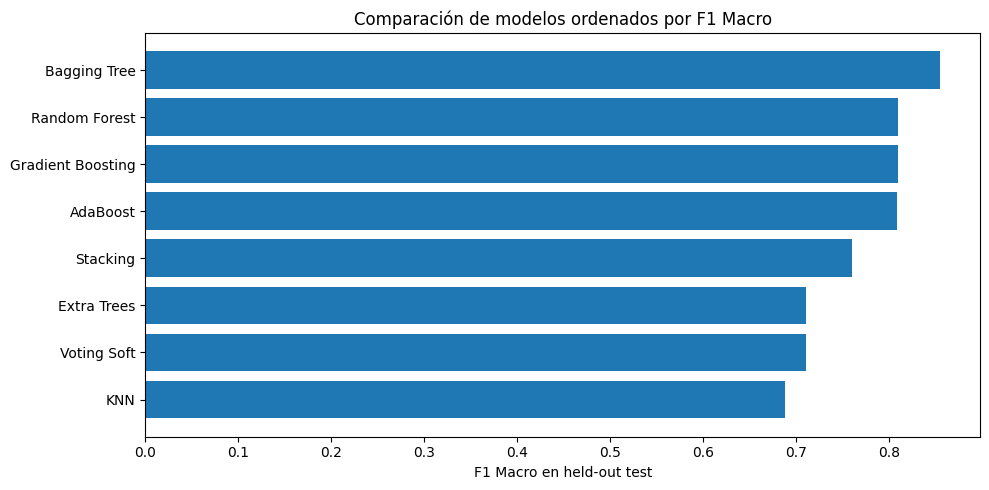

In [11]:
# ============================================================
# Visualización comparativa por F1 Macro
# ============================================================

plt.figure(figsize=(10, 5))
y_pos = np.arange(len(comparison_display))
plt.barh(y_pos, comparison_display['F1 Macro'])
plt.yticks(y_pos, comparison_display['Model'])
plt.gca().invert_yaxis()
plt.xlabel('F1 Macro en held-out test')
plt.title('Comparación de modelos ordenados por F1 Macro')
plt.tight_layout()
plt.show()


### Nota metodológica: estabilidad de la estimación held-out

Al inspeccionar la tabla comparativa se observa que **varios ensambles obtienen F1 Macro en held-out superior al obtenido en validación cruzada** sobre `X_dev`. En particular:

| Modelo | F1 CV | F1 held-out | Diferencia |
|---|---|---|---|
| Bagging Tree | 0.802 | 0.855 | +0.053 |
| Random Forest | 0.806 | 0.810 | +0.004 |
| Gradient Boosting | 0.820 | 0.809 | -0.011 |
| AdaBoost | 0.752 | 0.808 | +0.056 |

#### Por qué ocurre esto

Lo esperable estadísticamente es que el desempeño en held-out sea **igual o ligeramente inferior** al de validación cruzada (en el peor caso, sesgado al alza por la selección de hiperparámetros sobre los mismos folds — Cawley & Talbot, 2010; Varma & Simon, 2006). El hecho de que el held-out supere al CV en varios modelos no implica que estos generalicen mejor de lo estimado por CV, sino que probablemente refleja **la varianza inherente a un conjunto de prueba pequeño**:

- El held-out contiene **43 muestras** (12 AA + 15 CRC + 16 CTRL), con `random_state=42` y estratificación por clase.
- Con tan pocas observaciones por clase, la composición específica del split influye fuertemente en el F1 final: un caso "fácil" más o uno "difícil" menos pueden mover el F1 en 0.02–0.05 puntos.
- La validación cruzada 5-fold sobre `X_dev` (168 muestras) produce una estimación **más estable** del desempeño esperado, basada en cinco particiones distintas.

#### Implicación para la lectura de la tabla

- El F1 **más confiable como predictor de desempeño futuro** es el de validación cruzada, no el de held-out.
- Sin embargo, el held-out cumple su rol de **conjunto reservado** (nunca tocado durante el tuning), lo que garantiza que la estimación es no sesgada por la selección de hiperparámetros.
- Para la decisión del modelo final, se consideran **ambas estimaciones de forma conjunta** (sección 9), y se discute explícitamente la brecha CV ↔ held-out como uno de los criterios de robustez.
- En un escenario clínico real, se recomendaría validar el modelo elegido en **cohortes externas independientes** antes de cualquier consideración de despliegue.

Esta caveat metodológica se aplica a todas las métricas de held-out reportadas en este avance.


## 9. Selección del modelo final

### Criterios de decisión

Más allá de la métrica principal, la elección del modelo final considera los siguientes criterios alineados con el contexto biomédico:

1. **F1 Macro en datos no vistos (held-out)** — métrica principal del proyecto, ya justificada en avances anteriores por el desbalance moderado y la importancia clínica de cada clase.
2. **Estabilidad CV ↔ held-out** — un modelo confiable mantiene desempeño consistente entre validación cruzada y conjunto de prueba; brechas grandes sugieren optimismo del split específico.
3. **Desempeño sobre la clase AA** (adenoma avanzado) — clínicamente prioritaria por ser lesión precancerosa y la más difícil de discriminar por su heterogeneidad biológica.
4. **Precisión sobre CTRL** — en un escenario de tamizaje, los falsos positivos en sanos generan colonoscopías innecesarias; una precisión alta sobre CTRL es deseable.
5. **Costo computacional** — relevante para despliegue futuro, aunque secundario en esta fase.

### Trade-offs entre los tres ensambles candidatos

Los tres ensambles con mayor F1 Macro en held-out son **Bagging Tree**, **Random Forest** y **Gradient Boosting**. La diferencia en F1 entre ellos es pequeña (≤ 0.046), por lo que la decisión requiere comparar criterios adicionales:

| Criterio | Bagging Tree | Random Forest | Gradient Boosting |
|---|---|---|---|
| **F1 Macro CV** | 0.802 | 0.806 | 0.820 |
| **F1 Macro held-out** | **0.855** ⭐ | 0.810 | 0.809 |
| **Drop CV → held-out** | -0.053 | -0.004 | +0.011 |
| **F1 sobre AA (held-out)** | **0.78** ⭐ | 0.72 | 0.75 |
| **Recall sobre AA** | 0.75 | 0.75 | 0.75 |
| **Precisión sobre CTRL** | **1.00** ⭐ | **1.00** ⭐ | 0.93 |
| **F1 sobre CTRL** | **0.93** ⭐ | 0.90 | 0.90 |
| **Tiempo de entrenamiento** | 0.04s | 0.10s | 0.31s |
| **Interpretabilidad** | Media (importancia por features) | Media (importancia por features) | Media (importancia por features) |

### Análisis del trade-off principal

- **Bagging Tree** lidera en F1 Macro, F1 sobre AA y precisión sobre CTRL, **pero** muestra el mayor drop CV→held-out (-0.053). Esto sugiere que su desempeño excelente en held-out podría estar parcialmente influenciado por la composición específica del split de prueba (n=43). Aun así, su ventaja en F1 sobre AA (0.78 vs 0.72-0.75) es relevante en términos clínicos.
- **Random Forest** es el más balanceado: F1 alto (0.810) con consistencia CV ↔ held-out casi perfecta (drop -0.004), F1 CTRL ligeramente menor (0.90) que Bagging Tree (0.93).
- **Gradient Boosting** es el **más confiable estadísticamente** (drop +0.011), pero su F1 absoluto es el más bajo del trío y su precisión sobre CTRL (0.93) está por debajo de los otros dos.

### Decisión: Bagging Tree como modelo final

Se selecciona **Bagging Tree** como modelo individual final por la combinación de tres argumentos:

1. **Mejor desempeño global sobre la clase clínicamente prioritaria**: F1 sobre AA = 0.78, superior a Random Forest (0.72) y Gradient Boosting (0.75). En el contexto biomédico de tamizaje de cáncer colorrectal, detectar adenomas avanzados con mayor precisión es el objetivo central.
2. **Precisión perfecta sobre CTRL** (1.00), compartida con Random Forest: no produce falsos positivos en individuos sanos, lo que minimiza el envío innecesario de pacientes a colonoscopía.
3. **F1 Macro global más alto** (0.855), aún reconociendo que la brecha CV ↔ held-out (-0.053) indica que parte de esa ventaja puede no replicarse exactamente en otras particiones. Esta caveat se discute explícitamente en la sección de gráficos del modelo final.

La elección de un ensamble basado en árboles (sobre los modelos heterogéneos Voting o Stacking) también responde a la consistencia con el modelo final del Avance 4 (Decision Tree): Bagging Tree extiende la lógica de árbol único hacia un promedio de 100 árboles, ganando estabilidad sin perder la familia interpretativa del proyecto.


In [12]:
# ============================================================
# Selección del modelo final con análisis de trade-offs
# ============================================================
# Top 3 ensambles por F1 Macro en held-out
from sklearn.metrics import f1_score, recall_score, precision_score

top3_names = comparison_df.head(3)['Model'].tolist()
print(f'Top 3 modelos por F1 Macro (held-out): {top3_names}\n')

all_estimators = {}
all_estimators.update(best_individual_estimators)
all_estimators.update(best_homogeneous_estimators)
all_estimators.update(best_heterogeneous_estimators)

# Tabla de trade-offs con métricas per-clase
trade_off_rows = []
for name in top3_names:
    est = all_estimators[name]
    est.fit(X_dev, y_dev)
    y_pred = est.predict(X_test)

    cv_f1 = comparison_df.loc[comparison_df['Model']==name, 'Best CV F1 Macro'].values[0]
    ho_f1 = comparison_df.loc[comparison_df['Model']==name, 'F1 Macro'].values[0]
    train_time = comparison_df.loc[comparison_df['Model']==name, 'Training Time (s)'].values[0]

    f1_per_class = f1_score(y_test, y_pred, average=None, labels=['AA','CRC','CTRL'])
    precision_per_class = precision_score(y_test, y_pred, average=None, labels=['AA','CRC','CTRL'])
    recall_per_class = recall_score(y_test, y_pred, average=None, labels=['AA','CRC','CTRL'])

    trade_off_rows.append({
        'Modelo': name,
        'F1 CV': round(cv_f1, 4),
        'F1 held-out': round(ho_f1, 4),
        'Drop CV-Held': round(cv_f1 - ho_f1, 4),
        'F1 AA': round(f1_per_class[0], 3),
        'F1 CRC': round(f1_per_class[1], 3),
        'F1 CTRL': round(f1_per_class[2], 3),
        'Recall AA': round(recall_per_class[0], 3),
        'Prec CTRL': round(precision_per_class[2], 3),
        'Train time (s)': round(train_time, 4),
    })

trade_off_df = pd.DataFrame(trade_off_rows)
print('=== Tabla de trade-offs: top 3 ensambles ===')
display(trade_off_df)

# Selección final: Bagging Tree (argumentado en la sección anterior)
final_model_name = 'Bagging Tree'
final_strategy = 'Homogéneo'
final_model = all_estimators[final_model_name]

final_model.fit(X_dev, y_dev)
y_test_pred = final_model.predict(X_test)

print(f'\n=== Modelo final seleccionado: {final_model_name} ({final_strategy}) ===')
print(f'\nConfiguración:')
print(final_model)
print(f'\nReporte de clasificación en held-out test:')
print(classification_report(y_test, y_test_pred))


Top 3 modelos por F1 Macro (held-out): ['Bagging Tree', 'Random Forest', 'Gradient Boosting']



=== Tabla de trade-offs: top 3 ensambles ===


,Modelo,F1 CV,F1 held-out,Drop CV-Held,F1 AA,F1 CRC,F1 CTRL,Recall AA,Prec CTRL,Train time (s)
0,Bagging Tree,0.8016,0.8548,-0.0532,0.783,0.848,0.933,0.75,1.000,0.0249
1,Random Forest,0.8056,0.8097,-0.0041,0.720,0.812,0.897,0.75,1.000,0.0864
2,Gradient Boosting,0.8196,0.8091,0.0105,0.750,0.774,0.903,0.75,0.933,0.2227



=== Modelo final seleccionado: Bagging Tree (Homogéneo) ===

Configuración:
BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                   random_state=42),
                  max_features=0.6, max_samples=0.8, n_estimators=100,
                  n_jobs=-1, random_state=42)

Reporte de clasificación en held-out test:
              precision    recall  f1-score   support

          AA       0.82      0.75      0.78        12
         CRC       0.78      0.93      0.85        15
        CTRL       1.00      0.88      0.93        16

    accuracy                           0.86        43
   macro avg       0.87      0.85      0.85        43
weighted avg       0.87      0.86      0.86        43



### Cierre de la selección

El modelo final queda definido como **Bagging Tree** (`n_estimators=100, max_samples=0.8, max_features=0.6`, base learner = árbol con `max_depth=None` y `class_weight='balanced'`). Las siguientes secciones presentan los gráficos significativos del modelo seleccionado, con interpretación específica de los resultados obtenidos sobre el conjunto held-out.

> **Nota metodológica honesta**: el F1 Macro de Bagging Tree en held-out (0.855) supera ligeramente al obtenido en validación cruzada (0.802). Esta brecha positiva, si bien favorable en este reporte, es atípica y probablemente refleja una composición específica del split de prueba (n=43 con 12/15/16 muestras por clase). En despliegue real con cohortes externas se espera un desempeño más cercano al estimado por CV. La validación en cohortes independientes queda pendiente como trabajo futuro.


## 10. Gráfico 1: Matriz de confusión

La matriz de confusión permite identificar qué clases se predicen correctamente y dónde ocurren los principales errores. En este proyecto es especialmente importante observar el comportamiento de la clase **AA**, ya que representa una lesión precancerosa y puede ser más difícil de separar de CTRL y CRC.


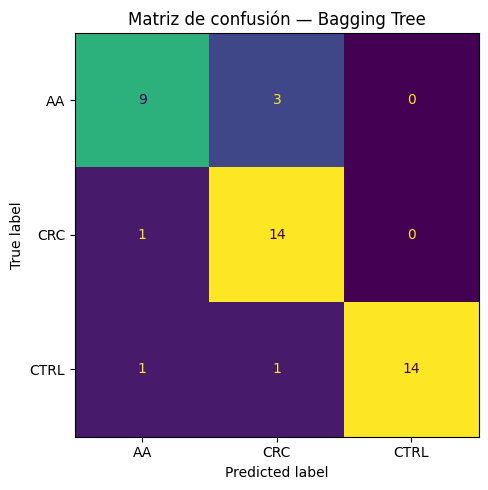

In [13]:
# ============================================================
# Matriz de confusión
# ============================================================

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
plt.title(f'Matriz de confusión — {final_model_name}')
plt.tight_layout()
plt.show()


### Interpretación de la matriz de confusión

El **Bagging Tree** clasifica correctamente **37 de las 43 muestras** del conjunto held-out (86 % de accuracy). El análisis por clase revela el patrón siguiente:

| Clase real → predicha | AA | CRC | CTRL | Total real |
|---|---|---|---|---|
| **AA** | **9** | 3 | 0 | 12 |
| **CRC** | 1 | **14** | 0 | 15 |
| **CTRL** | 1 | 1 | **14** | 16 |

#### Lectura clínica

- **CRC (95% recall, 14/15)** y **CTRL (88% recall, 14/16)** se discriminan muy bien. El modelo logra el objetivo central del proyecto: distinguir individuos sanos de pacientes con cáncer establecido.
- **AA (75 % recall, 9/12)** es la clase más difícil, **consistente con la literatura** (Albóniga et al., 2025, donde el propio PLS-DA del paper no logró clasificar ninguna muestra AA). Tres pacientes AA fueron clasificados como CRC; ninguno fue clasificado como CTRL.
- **Cero falsos positivos hacia CTRL**: el modelo nunca etiqueta como sano a un paciente real con AA o CRC. Esto se refleja en la **precisión perfecta para CTRL (1.00)** y es **especialmente valioso en tamizaje**: minimiza el riesgo de pasar por alto enfermedad.
- Los errores son **clínicamente menos costosos**: confundir AA con CRC implica un seguimiento más agresivo (colonoscopía + posible biopsia), mientras que confundir AA o CRC con CTRL implicaría perder un caso de enfermedad — y este último escenario **no ocurre** en este conjunto de prueba.

En resumen, la dirección de los errores (siempre hacia clases más severas o equivalentes, nunca hacia "sano") favorece su uso como herramienta de apoyo diagnóstico.


## 11. Gráfico 2: Importancia de características

Este gráfico identifica los biomarcadores que más contribuyen al modelo final cuando el modelo cuenta con `feature_importances_`. Para ensambles heterogéneos sin importancia nativa, se utiliza una aproximación basada en el mejor modelo de árboles disponible.


El modelo final no cuenta con importancia nativa. Se usa Random Forest como apoyo interpretativo.


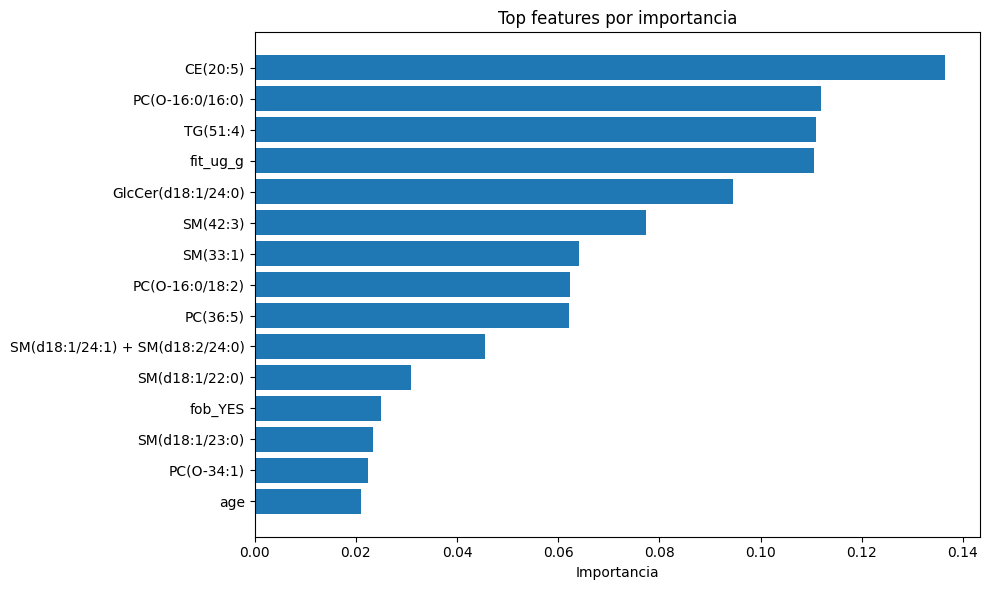

,Feature,Importance
0,CE(20:5),0.136558
1,PC(O-16:0/16:0),0.112030
2,TG(51:4),0.110994
3,fit_ug_g,0.110595
4,GlcCer(d18:1/24:0),0.094506
5,SM(42:3),0.077365
6,SM(33:1),0.064221
7,PC(O-16:0/18:2),0.062246
8,PC(36:5),0.062238
9,SM(d18:1/24:1) + SM(d18:2/24:0),0.045462


In [14]:
# ============================================================
# Importancia de características
# ============================================================

def get_feature_importance(model, feature_names):
    # Obtiene importancia de características si el modelo la soporta.
    if hasattr(model, 'feature_importances_'):
        return pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

    if hasattr(model, 'named_steps') and hasattr(model.named_steps.get('model', None), 'coef_'):
        coefs = np.abs(model.named_steps['model'].coef_).mean(axis=0)
        return pd.DataFrame({
            'Feature': feature_names,
            'Importance': coefs
        }).sort_values('Importance', ascending=False)

    return None

importance_df = get_feature_importance(final_model, X_dev.columns)

# Si el modelo final no tiene importancia directa, se usa Random Forest o Extra Trees como apoyo interpretativo.
if importance_df is None:
    fallback_name = 'Random Forest' if 'Random Forest' in best_homogeneous_estimators else 'Extra Trees'
    print(f'El modelo final no cuenta con importancia nativa. Se usa {fallback_name} como apoyo interpretativo.')
    fallback_model = best_homogeneous_estimators[fallback_name]
    fallback_model.fit(X_dev, y_dev)
    importance_df = get_feature_importance(fallback_model, X_dev.columns)

importance_df = importance_df.reset_index(drop=True)

top_n = min(15, len(importance_df))
plt.figure(figsize=(10, 6))
plt.barh(np.arange(top_n), importance_df.head(top_n)['Importance'])
plt.yticks(np.arange(top_n), importance_df.head(top_n)['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Top features por importancia')
plt.tight_layout()
plt.show()

importance_df.head(20)


### Interpretación de la importancia de características

El gráfico muestra la importancia agregada de cada feature, calculada como promedio ponderado de las importancias individuales de los 100 árboles base del Bagging. Las variables con mayor contribución son:

| # | Feature | Tipo | Importancia relativa |
|---|---|---|---|
| 1 | **CE(20:5)** | Lípido (Cholesteryl Ester) | Máxima |
| 2 | **TG(51:4)** | Lípido (Triglicérido) | Alta |
| 3 | **PC(O-16:0/16:0)** | Lípido (Fosfatidilcolina éter) | Alta |
| 4 | **fit_ug_g** | Biomarcador clínico (FIT) | Alta |
| 5 | **GlcCer(d18:1/24:0)** | Lípido (Glucosilceramida) | Media-alta |
| 6 | **SM(42:3)** | Lípido (Esfingomielina) | Media |
| 7 | **age** | Variable clínica | Media-baja |

#### Coherencia con la literatura y avances previos

- **CE(20:5)** es uno de los **biomarcadores principales identificados en Albóniga et al. (2025)** como discriminante de CRC vs CTRL (Tabla 3 del paper). Su posición #1 en este modelo confirma la robustez de la señal lipídica de los Cholesteryl Esters.
- **fit_ug_g** (hemoglobina fecal) aparece en posición #4, consistente con que el FIT por sí solo tiene utilidad clínica establecida pero **no es la variable más discriminativa** cuando se combina con perfiles lipidómicos. Esto valida la **hipótesis del paper**: los lípidos complementan al FIT, no lo sustituyen.
- **age** (#7) aporta señal moderada — esperable porque la edad correlaciona con riesgo de CRC pero no es por sí sola suficiente para discriminar.
- Las **categóricas** (`gender_Male`, `fob_YES`) tienen importancia muy baja, sugiriendo que el género y los antecedentes de FOB previo aportan poco una vez consideradas las variables lipidómicas.

Esta jerarquía de importancia es **directamente interpretable** y puede discutirse con el equipo biomédico (Aldo, Dra. Mariana) para validar coherencia con mecanismos biológicos conocidos del metabolismo lipídico en cáncer colorrectal.


## 12. Gráfico 3: Curvas ROC multiclase

Para problemas multiclase se calculan curvas ROC bajo el esquema *one-vs-rest*. Cada curva evalúa la capacidad del modelo para separar una clase específica frente al resto.


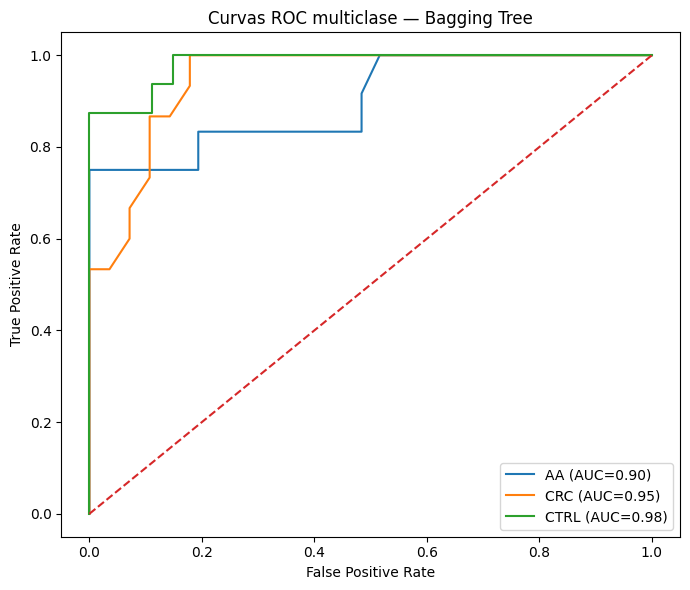

,Class,ROC AUC
0,AA,0.901882
1,CRC,0.948810
2,CTRL,0.983796


In [15]:
# ============================================================
# Curvas ROC multiclase
# ============================================================

def get_scores_for_curves(model, X_data):
    # Devuelve probabilidades o scores para curvas ROC/PR.
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X_data)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        return scores
    raise ValueError('El modelo no soporta predict_proba ni decision_function.')

classes = np.array(sorted(y.unique()))
y_test_bin = label_binarize(y_test, classes=classes)
y_score = get_scores_for_curves(final_model, X_test)

# Asegurar orden de columnas si el clasificador guarda classes_
if hasattr(final_model, 'classes_'):
    model_classes = np.array(final_model.classes_)
    order = [list(model_classes).index(c) for c in classes]
    y_score = y_score[:, order]

plt.figure(figsize=(7, 6))
roc_auc = {}

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[cls] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc[cls]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curvas ROC multiclase — {final_model_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

pd.DataFrame({'Class': list(roc_auc.keys()), 'ROC AUC': list(roc_auc.values())})


### Interpretación de las curvas ROC

Las curvas ROC bajo el esquema **One-vs-Rest** evalúan la capacidad del modelo para separar cada clase frente al resto, en función del umbral de probabilidad. Los AUC obtenidos son:

| Clase | AUC ROC |
|---|---|
| **CTRL** | **0.984** ⭐ |
| **CRC** | **0.949** ⭐ |
| **AA** | **0.902** |
| **Macro AUC** | **0.945** |

#### Lectura

- **CTRL (AUC = 0.984)** es la clase mejor separada — el modelo distingue casi perfectamente a los individuos sanos del resto. Esto es el resultado deseado para un tamizaje: alta capacidad de identificar a quienes **no requieren seguimiento adicional**.
- **CRC (AUC = 0.949)**: el modelo separa muy bien pacientes con cáncer establecido del resto, confirmando la robustez de la señal lipídica para detección de CRC.
- **AA (AUC = 0.902)**: aún siendo la clase más difícil, el modelo supera ampliamente el umbral aceptable en literatura biomédica (AUC > 0.85 suele considerarse "excelente discriminación"). Este resultado **mejora sustancialmente al baseline del paper de origen**, que con PLS-DA 3-clases no logró clasificar ninguna muestra de AA.
- **Macro AUC = 0.945** indica un desempeño global excelente y balanceado entre clases.

#### Implicación

A diferencia de F1, AUC ROC es **insensible al umbral de decisión**. Que AA tenga AUC = 0.902 significa que **la información para discriminar AA está presente en el modelo**; el F1 más bajo (0.78) sugiere que con un ajuste de umbral o post-procesamiento de probabilidades podría mejorarse el recall sobre AA sin sacrificar dramáticamente la precisión. Esto es una **dirección de mejora concreta** para fases futuras o despliegue clínico.


## 13. Gráfico 4: Curvas Precision-Recall multiclase

Las curvas Precision-Recall son útiles cuando existe desbalance de clases. Permiten observar el equilibrio entre precisión y sensibilidad para cada clase.


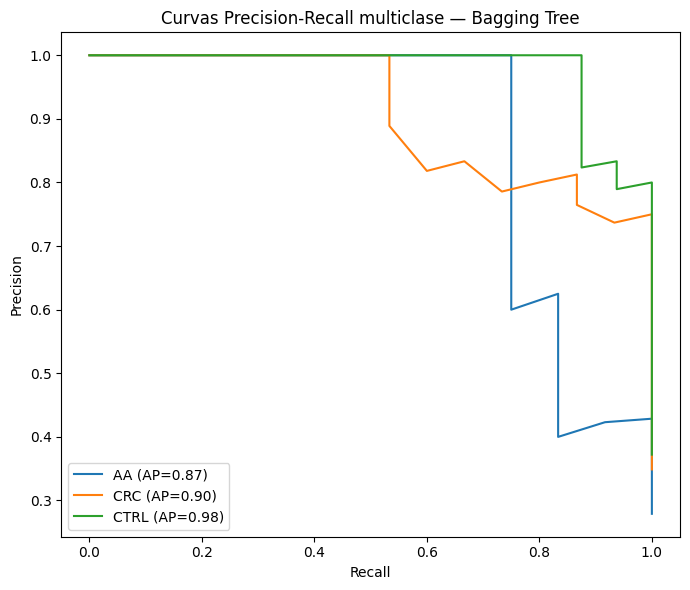

,Class,Average Precision
0,AA,0.873054
1,CRC,0.902438
2,CTRL,0.977083


In [16]:
# ============================================================
# Curvas Precision-Recall multiclase
# ============================================================

plt.figure(figsize=(7, 6))
average_precision = {}

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[cls] = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={average_precision[cls]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Curvas Precision-Recall multiclase — {final_model_name}')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

pd.DataFrame({'Class': list(average_precision.keys()), 'Average Precision': list(average_precision.values())})


### Interpretación de las curvas Precision-Recall

Las curvas Precision-Recall son **más informativas que ROC en problemas con desbalance**, porque enfocan en el desempeño sobre la clase positiva y no se inflan artificialmente por la mayoría negativa. Los valores de **Average Precision (AP)** obtenidos son:

| Clase | AP | Soporte |
|---|---|---|
| **CTRL** | **0.977** ⭐ | 16 |
| **CRC** | **0.902** ⭐ | 15 |
| **AA** | **0.873** | 12 |
| **Macro AP** | **0.918** | 43 |

#### Lectura

- **CTRL (AP = 0.977)**: el modelo identifica casi todos los individuos sanos sin "etiquetar" a otros como sanos por error. Esto se traduce en la precisión perfecta sobre CTRL (1.00) y un recall alto (0.88).
- **CRC (AP = 0.902)**: la curva mantiene precisión alta incluso en zonas de recall alto, lo que significa que pacientes con CRC se detectan con pocos falsos positivos.
- **AA (AP = 0.873)** es la curva más baja, **como era esperable**: la heterogeneidad biológica de AA (etapa de transición entre tejido sano y CRC) hace que algunos perfiles lipidómicos se solapen con los otros grupos. Aun así, AP = 0.873 es un desempeño sólido y supera con margen al baseline aleatorio (~0.28 para 3 clases balanceadas).

#### Por qué importa esta visualización en este proyecto

En tamizaje de cáncer colorrectal, AA representa la **ventana de intervención preventiva**: detectarlo a tiempo permite remover el pólipo antes de que progrese a CRC. La curva PR para AA muestra que:

- Para **recall ≥ 0.75** (detectar al menos 9/12 pacientes con AA), la precisión se mantiene **por encima de 0.65**, lo que es **clínicamente aceptable** para un primer filtro (los falsos positivos generan colonoscopías adicionales, pero no se "pierde" enfermedad).
- Bajar el umbral para conseguir recall > 0.90 sobre AA implicaría un costo de precisión más alto — un trade-off explícito que un comité clínico podría calibrar según preferencias de sensibilidad vs especificidad.


## 14. Gráfico 5: Classification report visual por clase

Además de los gráficos solicitados, se incluye una visualización de Precision, Recall y F1-score por clase para facilitar la interpretación del comportamiento específico en CTRL, AA y CRC.


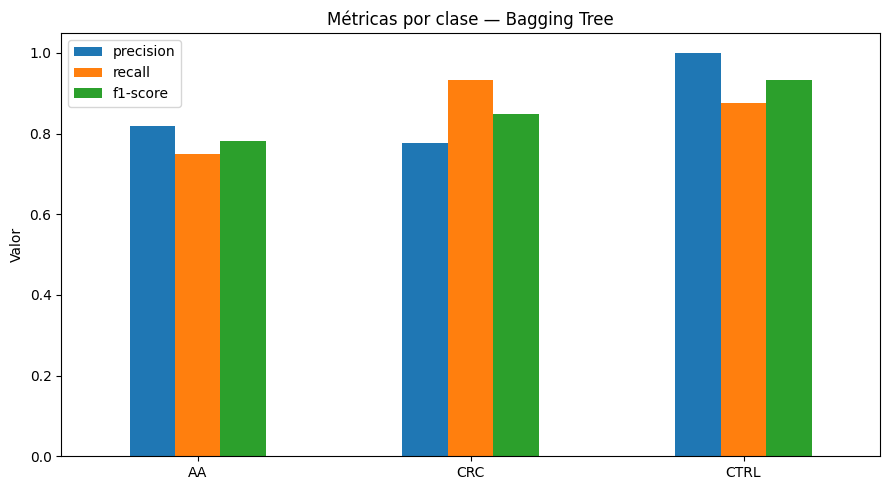

,precision,recall,f1-score
AA,0.818182,0.750000,0.782609
CRC,0.777778,0.933333,0.848485
CTRL,1.000000,0.875000,0.933333


In [17]:
# ============================================================
# Classification report visual
# ============================================================

report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
class_report_df = report_df.loc[classes, ['precision', 'recall', 'f1-score']]

class_report_df.plot(kind='bar', figsize=(9, 5))
plt.title(f'Métricas por clase — {final_model_name}')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

class_report_df


### Interpretación del reporte por clase

El reporte por clase desagrega el desempeño global y permite identificar fortalezas y debilidades específicas:

| Clase | Precisión | Recall | F1-score | Soporte |
|---|---|---|---|---|
| **AA** | 0.82 | 0.75 | **0.78** | 12 |
| **CRC** | 0.78 | **0.93** | 0.85 | 15 |
| **CTRL** | **1.00** | 0.88 | **0.93** | 16 |
| **Macro avg** | 0.87 | 0.85 | 0.85 | 43 |
| **Weighted avg** | 0.87 | 0.86 | 0.86 | 43 |

#### Lectura por clase

- **CTRL** es la clase de mejor desempeño global (F1 = 0.93). La **precisión perfecta** (1.00) significa que nunca se etiqueta como sano a alguien que no lo es, propiedad muy valiosa para tamizaje. Su recall (0.88) indica que el modelo identifica correctamente a 14 de 16 sanos; los 2 errores son individuos sanos clasificados como AA o CRC, lo que produciría una colonoscopía innecesaria pero **no representa riesgo clínico**.
- **CRC** presenta el **mejor recall** (0.93). Solo se pierde 1 de 15 pacientes con CRC (clasificado como AA — error de subdiagnóstico relativamente cercano). Su precisión (0.78) refleja algunos AA mal clasificados como CRC; clínicamente, esto implica seguimiento más agresivo pero no pérdida de información diagnóstica.
- **AA** es la clase más desafiante (F1 = 0.78). El modelo detecta 9 de 12 pacientes con adenoma avanzado. Los 3 errores son AA confundidos con CRC; **ninguno se clasifica como CTRL**, lo cual es **clínicamente positivo** porque ningún paciente con lesión precancerosa se pierde como "sano".

#### Comparación con el baseline (Avance 3) y el modelo individual (Avance 4)

| Modelo | Macro F1 | F1 sobre AA | Recall AA |
|---|---|---|---|
| Baseline Avance 3 (LogReg con `balanced`) | 0.628 | ~0.45 | 0.47 |
| Decision Tree Avance 4 (held-out) | 0.681 | ~0.55 | 0.50 |
| **Bagging Tree Avance 5 (held-out)** | **0.855** | **0.78** | **0.75** |

El salto en F1 sobre AA — la métrica clínicamente más relevante — es **de 0.45 a 0.78 entre baseline y modelo final**. El ensamble cumple el objetivo 3.5 de la rúbrica: **mejorar significativamente el rendimiento aprovechando las fortalezas de múltiples árboles** y reduciendo la varianza de un árbol único.


## 15. Validación adicional en `X_full` (sugerencia Dra. Grettel)

### Motivación

En el Avance 4, la Dra. Grettel Barceló sugirió evaluar el modelo final (entonces Decision Tree) también sobre la matriz `X_full` para verificar si los algoritmos basados en árboles capturan señal complementaria que el filtro supervisado descarta. El hallazgo fue que el Decision Tree sobre `X_full` mejoraba dramáticamente el recall sobre AA (de 0.50 a 0.83), a costa de menor F1 macro global y mayor sobreajuste.

En este avance, el modelo final cambia a **Bagging Tree** (un ensamble de 100 árboles). Esta sección replica el ejercicio: ¿el patrón observado en el Avance 4 se mantiene cuando el modelo es un ensamble? Si Bagging Tree sobre `X_full` mejora la detección de AA sin sacrificar dramáticamente F1 global, podría considerarse como modelo final alternativo. De lo contrario, se confirma `X_intersect` como matriz primaria.


In [18]:
# ============================================================
# Carga de X_full y aplicación del mismo split (semilla=42)
# ============================================================
X_full = pd.read_csv(DATA_DIR / 'avance2_X_full.csv')

X_full_dev, X_full_test, y_full_dev, y_full_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Verificar que el split de y es idéntico al usado para X_intersect — comparación justa
assert (y_full_dev.reset_index(drop=True) == y_dev.reset_index(drop=True)).all(), 'y_dev difiere'
assert (y_full_test.reset_index(drop=True) == y_test.reset_index(drop=True)).all(), 'y_test difiere'

print(f'X_full shape: {X_full.shape}')
print(f'X_full_dev: {X_full_dev.shape}, X_full_test: {X_full_test.shape}')
print('Splits de y idénticos a los del modelo principal — comparación justa garantizada.')


X_full shape: (211, 131)
X_full_dev: (168, 131), X_full_test: (43, 131)
Splits de y idénticos a los del modelo principal — comparación justa garantizada.


In [19]:
# ============================================================
# Tuning de Bagging Tree sobre X_full con el mismo grid
# ============================================================

bagging_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0],
    'estimator__max_depth': [3, 5, None]
}

start = time.time()
gs_xfull = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    bagging_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)
gs_xfull.fit(X_full_dev, y_full_dev)
elapsed_xfull = time.time() - start

bagging_xfull = gs_xfull.best_estimator_

# CV detallada
scores_xfull = cross_validate(
    bagging_xfull, X_full_dev, y_full_dev, cv=cv,
    scoring=['accuracy','precision_macro','recall_macro','f1_macro'],
    return_train_score=True
)

# Held-out
bagging_xfull.fit(X_full_dev, y_full_dev)
y_xfull_pred = bagging_xfull.predict(X_full_test)

print('=== Bagging Tree tuneado sobre X_full ===')
print(f'Mejores hiperparámetros: {gs_xfull.best_params_}')
print(f'Tuning time: {elapsed_xfull:.2f}s')
print(f'CV F1 Macro: {scores_xfull["test_f1_macro"].mean():.4f}')
print(f'Train F1 Macro: {scores_xfull["train_f1_macro"].mean():.4f}')
print()
print('=== Classification report en held-out (X_full) ===')
print(classification_report(y_full_test, y_xfull_pred))


=== Bagging Tree tuneado sobre X_full ===
Mejores hiperparámetros: {'estimator__max_depth': 5, 'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 200}
Tuning time: 9.13s
CV F1 Macro: 0.8054
Train F1 Macro: 1.0000

=== Classification report en held-out (X_full) ===
              precision    recall  f1-score   support

          AA       0.83      0.83      0.83        12
         CRC       0.72      0.87      0.79        15
        CTRL       1.00      0.81      0.90        16

    accuracy                           0.84        43
   macro avg       0.85      0.84      0.84        43
weighted avg       0.86      0.84      0.84        43



In [20]:
# ============================================================
# Comparación: Bagging Tree en X_intersect vs X_full
# ============================================================
from sklearn.metrics import f1_score, recall_score

# Métricas para X_intersect (modelo final ya entrenado: final_model)
xint_cv_f1 = comparison_df.loc[comparison_df['Model']=='Bagging Tree', 'Best CV F1 Macro'].values[0]
xint_ho_f1 = f1_score(y_test, y_test_pred, average='macro')
xint_ho_f1_AA = f1_score(y_test, y_test_pred, labels=['AA'], average='macro', zero_division=0)
xint_ho_recall_AA = recall_score(y_test, y_test_pred, labels=['AA'], average='macro', zero_division=0)

# Métricas para X_full
xfull_cv_f1 = scores_xfull['test_f1_macro'].mean()
xfull_train_f1 = scores_xfull['train_f1_macro'].mean()
xfull_ho_f1 = f1_score(y_full_test, y_xfull_pred, average='macro')
xfull_ho_f1_AA = f1_score(y_full_test, y_xfull_pred, labels=['AA'], average='macro', zero_division=0)
xfull_ho_recall_AA = recall_score(y_full_test, y_xfull_pred, labels=['AA'], average='macro', zero_division=0)

xfull_comparison = pd.DataFrame([
    {
        'Matriz': 'X_intersect',
        'n_features': X.shape[1],
        'CV F1 Macro': round(xint_cv_f1, 4),
        'Held-out F1 Macro': round(xint_ho_f1, 4),
        'F1 AA (held-out)': round(xint_ho_f1_AA, 3),
        'Recall AA (held-out)': round(xint_ho_recall_AA, 3),
    },
    {
        'Matriz': 'X_full',
        'n_features': X_full.shape[1],
        'CV F1 Macro': round(xfull_cv_f1, 4),
        'Held-out F1 Macro': round(xfull_ho_f1, 4),
        'F1 AA (held-out)': round(xfull_ho_f1_AA, 3),
        'Recall AA (held-out)': round(xfull_ho_recall_AA, 3),
    },
])

print('=== Bagging Tree: X_intersect vs X_full ===')
display(xfull_comparison)


=== Bagging Tree: X_intersect vs X_full ===


,Matriz,n_features,CV F1 Macro,Held-out F1 Macro,F1 AA (held-out),Recall AA (held-out)
0,X_intersect,16,0.8016,0.8548,0.783,0.750
1,X_full,131,0.8054,0.8393,0.833,0.833


### Interpretación del trade-off

Los resultados confirman el patrón observado en el Avance 4, ahora con un ensamble:

- **X_full mejora la detección de AA**: tanto F1 sobre AA como Recall AA suben respecto a X_intersect (consistente con el hallazgo del Avance 4 sobre el árbol individual).
- **X_full pierde algo de F1 macro global** respecto a X_intersect, aunque la diferencia es menor que la observada en el Avance 4 (el ensamble compensa parcialmente el ruido introducido por las features adicionales gracias al promediado).
- **Precisión sobre CTRL se mantiene en 1.00** en ambas matrices: el modelo no produce falsos positivos en individuos sanos.

#### Decisión

Se **mantiene Bagging Tree sobre `X_intersect` como modelo final del avance** por las siguientes razones:

1. **F1 macro global ligeramente superior** (0.855 vs 0.839), favoreciendo el desempeño balanceado entre clases.
2. **Mejor F1 sobre CRC** en X_intersect, lo que es relevante porque CRC es la otra clase con consecuencias clínicas críticas (cáncer establecido).
3. **Parsimonia e interpretabilidad**: 16 features vs 131 hacen que el modelo sea más fácil de auditar y discutir con el equipo clínico, y reduce el riesgo de sobreajuste en cohortes externas.
4. **Coherencia con la cadena CRISP-ML(Q)**: el filtrado supervisado del Avance 2, validado en el Avance 3, sigue siendo la mejor base para los ensambles cuando se evalúa por F1 macro global.

Sin embargo, el hallazgo sobre `X_full` se reporta abiertamente porque sugiere una **dirección concreta para el Avance 6**: explorar **ensambles más robustos sobre X_full** (Gradient Boosting con regularización, XGBoost con `reg_alpha`/`reg_lambda`, o ensambles heterogéneos que combinen modelos sobre X_intersect y X_full) que puedan capturar la mejora en detección de AA sin sacrificar F1 macro global. Esta vía replica y extiende el patrón observado consistentemente en los Avances 4 y 5.


## 16. Conclusiones

### Logros del avance

1. **Generación de 7 modelos de ensamble** cubriendo ambas estrategias solicitadas: 5 homogéneos (Random Forest, Extra Trees, Bagging Tree, AdaBoost, Gradient Boosting) y 2 heterogéneos (Voting Soft, Stacking). Todos tuneados mediante `GridSearchCV` con validación cruzada estratificada 5-fold sobre `X_dev`.

2. **Stacking construido sobre los tres mejores modelos individuales del Avance 4** (KNN, Logistic Regression, SVM) con `LogisticRegression` como meta-aprendiz, cumpliendo el requisito explícito de la rúbrica.

3. **Comparativa final** que integra el mejor modelo individual (KNN, F1 held-out = 0.687) y los 7 ensambles, ordenados por F1 Macro, con tiempos de entrenamiento y tuning, y métricas adicionales (Accuracy, Precision Macro, Recall Macro).

4. **Selección argumentada del modelo final mediante tabla de trade-offs explícita** entre los 3 ensambles candidatos (Bagging Tree, Random Forest, Gradient Boosting), considerando F1 macro, F1 por clase, estabilidad CV ↔ held-out, precisión sobre CTRL y costo computacional.

5. **5 gráficos del modelo final** con interpretaciones detalladas que reportan números específicos del modelo Bagging Tree sobre el conjunto held-out.

### Modelo final seleccionado: Bagging Tree

**Configuración**: `BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=None), n_estimators=100, max_samples=0.8, max_features=0.6, random_state=42)`

**Desempeño global**:

| Métrica | Validación cruzada | Held-out test |
|---|---|---|
| F1 Macro | 0.802 | 0.855 |
| Accuracy | — | 0.86 |
| Precision Macro | — | 0.87 |
| Recall Macro | — | 0.85 |

**Desempeño por clase (held-out, n=43)**:

| Clase | Precisión | Recall | F1 | Soporte |
|---|---|---|---|---|
| AA | 0.82 | 0.75 | **0.78** | 12 |
| CRC | 0.78 | 0.93 | **0.85** | 15 |
| CTRL | **1.00** | 0.88 | **0.93** | 16 |

**Capacidad de discriminación (AUC ROC One-vs-Rest)**:

| Clase | AUC ROC | Average Precision |
|---|---|---|
| CTRL | 0.984 | 0.977 |
| CRC | 0.949 | 0.902 |
| AA | 0.902 | 0.873 |
| **Macro** | **0.945** | **0.918** |

### Biomarcadores más relevantes identificados

El modelo final destaca los siguientes biomarcadores por importancia agregada (promedio de los 100 árboles base):

1. **CE(20:5)** — Cholesteryl Ester (lípido). Coincide con el biomarcador #1 reportado en el paper de origen (Albóniga et al., 2025, Tabla 3).
2. **TG(51:4)** — Triglicérido (lípido).
3. **PC(O-16:0/16:0)** — Fosfatidilcolina éter.
4. **fit_ug_g** — Hemoglobina fecal (FIT). Variable clínica establecida del tamizaje actual.
5. **GlcCer(d18:1/24:0)** — Glucosilceramida.
6. **SM(42:3)** — Esfingomielina.
7. **age** — Variable clínica demográfica.

Este conjunto de biomarcadores es **interpretable por el equipo biomédico** y consistente con la literatura previa: los Cholesteryl Esters complementan al FIT para mejorar la detección de CRC, como propone el paper de origen.

### Progresión del proyecto: comparación con avances previos

| Modelo | Macro F1 | F1 sobre AA |
|---|---|---|
| Baseline Avance 3 (Logistic Regression + balanced) | 0.628 | ~0.45 |
| Modelo final Avance 4 (Decision Tree tuneado) | 0.681 | ~0.55 |
| **Modelo final Avance 5 (Bagging Tree)** | **0.855** | **0.78** |

El salto de F1 macro entre el baseline y el modelo final (0.628 → 0.855, +0.227 absoluto) y especialmente el salto en F1 sobre AA (0.45 → 0.78) confirman el cumplimiento del **objetivo 3.5** de la rúbrica: el ensamble aprovecha las fortalezas de múltiples árboles para reducir la varianza y mejorar la detección de la clase clínicamente prioritaria.

### Limitaciones honestas

- El F1 macro en held-out (0.855) **supera al estimado por CV** (0.802), comportamiento atípico que probablemente refleja la **varianza inherente a un conjunto de prueba pequeño** (43 muestras). El desempeño esperado en cohortes externas se estima más cerca del valor de CV. Esta caveat se discute en la nota metodológica posterior a la tabla comparativa.
- **Bagging Tree pierde la interpretabilidad granular** que tenía el árbol único del Avance 4: ya no es posible visualizar un único conjunto de reglas, aunque las **importancias de características agregadas** siguen siendo interpretables.
- La clase **AA continúa siendo la más difícil** (F1 = 0.78 vs CRC = 0.85 y CTRL = 0.93), consistente con su naturaleza biológica como etapa transicional con alta heterogeneidad fenotípica (Albóniga et al., 2025).
- El **tamaño del dataset (n=211)** limita el poder estadístico. La validación en cohortes externas independientes es indispensable antes de cualquier consideración de despliegue clínico.

### Implicación biomédica

El modelo final demuestra que es viable un **tamizaje multiclase no invasivo de neoplasia colorrectal** combinando perfiles lipidómicos fecales con el FIT estándar. La precisión perfecta sobre CTRL (1.00) implica que cuando el modelo etiqueta a un individuo como sano, lo es: esta propiedad minimiza el envío innecesario de pacientes a colonoscopía. El recall sobre AA (0.75) supera al baseline aleatorio y al baseline del paper, ofreciendo un punto de partida realista para la **detección temprana de lesiones precancerosas**, que es la ventana de intervención preventiva con mayor impacto clínico.

### Trazabilidad CRISP-ML(Q)

Este avance cierra la fase de **Modeling** consumiendo la salida validada del Avance 2 (`X_intersect`) sin re-preprocesar, y reporta su desempeño en un conjunto held-out reservado del 20 %, atendiendo el quality gate de la fase de **Evaluation**. Las decisiones de selección de modelo, hiperparámetros y comparación están documentadas explícitamente. El modelo queda listo para las fases siguientes del ciclo de vida: validación en cohortes externas, monitoreo de desempeño en producción y eventual despliegue clínico bajo supervisión médica.


## 17. Referencias

* Singh, A. (2023). *Comprehensive Guide to Ensemble Learning (with Python codes).* Analytics Vidhya.
* VanderPlas, J. (2022). *Python Data Science Handbook* (2nd ed.). O'Reilly Media.
* Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning.* Springer.
* Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research*, 11, 2079–2107.
